In [2]:
!ls

best_float32.tflite  best_int8.tflite  best.pt	Placas.zip  sample_data


In [4]:
!unzip Placas.zip

Archive:  Placas.zip
   creating: Placas/
  inflating: Placas/ADG22H.jpg       
  inflating: Placas/AFX91C.jpg       
  inflating: Placas/AOZ48G.jpg       
  inflating: Placas/AZA70F.jpg       
  inflating: Placas/BDV08.jpg        
  inflating: Placas/CIW062.jpg       
  inflating: Placas/DBI463.jpg       
  inflating: Placas/DHT578.png       
  inflating: Placas/DIF77H.jpg       
  inflating: Placas/DJN996.jpg       
  inflating: Placas/DJY681.jpg       
  inflating: Placas/DKU983.jpg       
  inflating: Placas/DQS096.jpg       
  inflating: Placas/DUL56G.jpg       
  inflating: Placas/EBS862.jpg       
  inflating: Placas/EFW512.jpg       
  inflating: Placas/EOS64D.jpg       
  inflating: Placas/EZI04D.jpg       
  inflating: Placas/FGL91C.jpg       
  inflating: Placas/FOY022.jpg       
  inflating: Placas/FPM832.jpg       
  inflating: Placas/FQX673.jpg       
  inflating: Placas/FSY718.jpg       
  inflating: Placas/FZM790.jpg       
  inflating: Placas/FZR555.jpg       
  inflat

In [5]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.6 MB/s eta 0:00:00


In [37]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np
from ultralytics.utils.plotting import plot_results
from ultralytics import YOLO
from IPython.display import display
from PIL import Image


In [24]:
model = YOLO("yolov8n.pt")

In [ ]:
model.train(
    data="/content/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspectiv

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b7e1649f4a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [10]:
plot_results('results.csv')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
¡Listo! Se ha guardado el archivo 'results.png' en tu directorio actual con el formato nativo de YOLO.


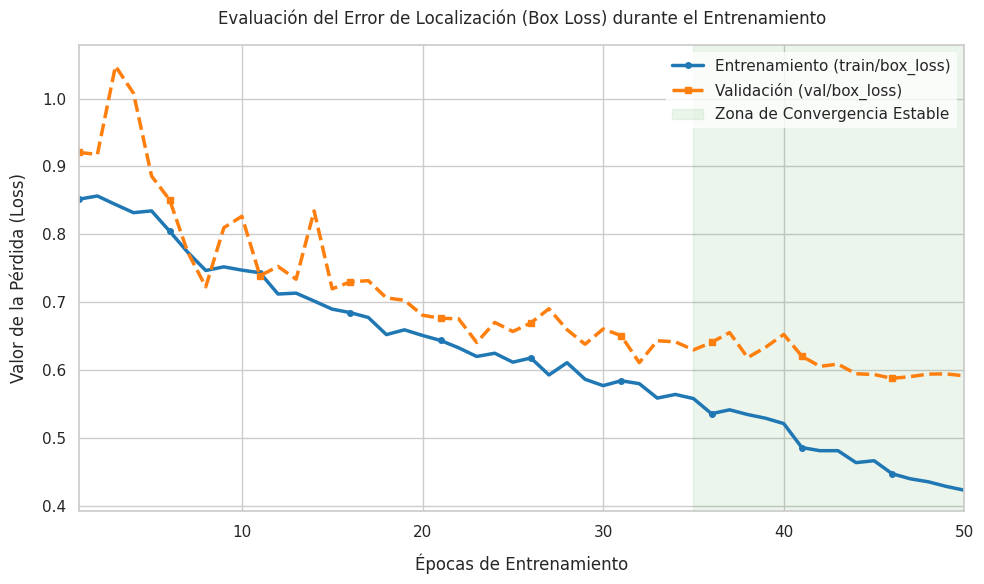

In [16]:
sns.set_theme(style="whitegrid")

df = pd.read_csv('results.csv')
df.columns = df.columns.str.strip()

plt.figure(figsize=(10, 6))

plt.plot(df['epoch'], df['train/box_loss'],
         label='Entrenamiento (train/box_loss)',
         color='#1f77b4', linewidth=2.5, marker='o', markersize=4, markevery=5)

plt.plot(df['epoch'], df['val/box_loss'],
         label='Validación (val/box_loss)',
         color='#ff7f0e', linewidth=2.5, linestyle='--', marker='s', markersize=4, markevery=5)

plt.title('Evaluación del Error de Localización (Box Loss) durante el Entrenamiento', pad=15)
plt.xlabel('Épocas de Entrenamiento', labelpad=10)
plt.ylabel('Valor de la Pérdida (Loss)', labelpad=10)
plt.xlim(1, df['epoch'].max())

plt.axvspan(35, df['epoch'].max(), color='green', alpha=0.08, label='Zona de Convergencia Estable')

plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.savefig('sustentacion_box_loss.png', dpi=300)
plt.show()

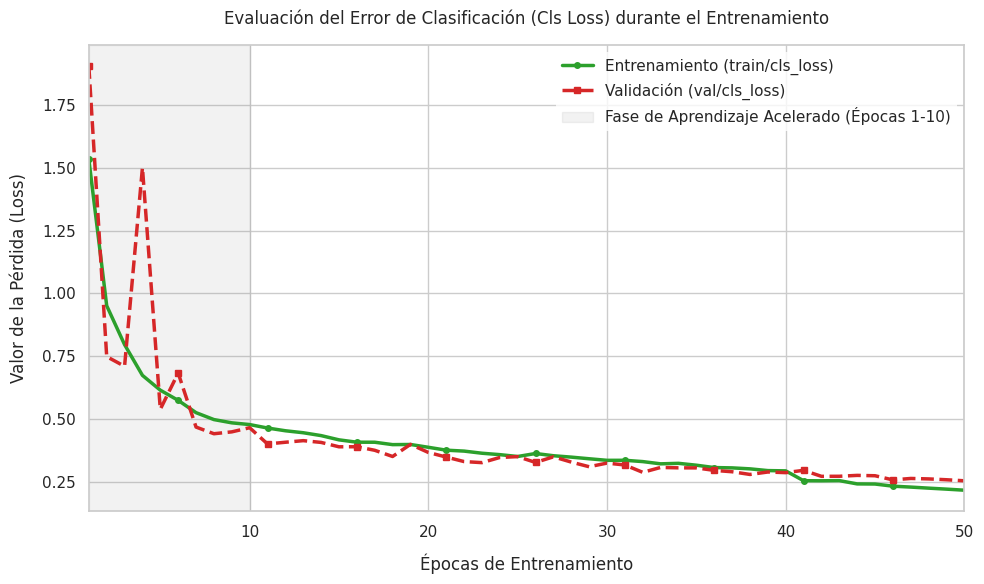

In [18]:
df = pd.read_csv('results.csv')
df.columns = df.columns.str.strip()
plt.figure(figsize=(10, 6))

plt.plot(df['epoch'], df['train/cls_loss'],
         label='Entrenamiento (train/cls_loss)',
         color='#2ca02c', linewidth=2.5, marker='o', markersize=4, markevery=5)

plt.plot(df['epoch'], df['val/cls_loss'],
         label='Validación (val/cls_loss)',
         color='#d62728', linewidth=2.5, linestyle='--', marker='s', markersize=4, markevery=5)

plt.title('Evaluación del Error de Clasificación (Cls Loss) durante el Entrenamiento', pad=15)
plt.xlabel('Épocas de Entrenamiento', labelpad=10)
plt.ylabel('Valor de la Pérdida (Loss)', labelpad=10)
plt.xlim(1, df['epoch'].max())

plt.axvspan(1, 10, color='gray', alpha=0.1, label='Fase de Aprendizaje Acelerado (Épocas 1-10)')

plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.savefig('sustentacion_cls_loss.png', dpi=300)
plt.show()

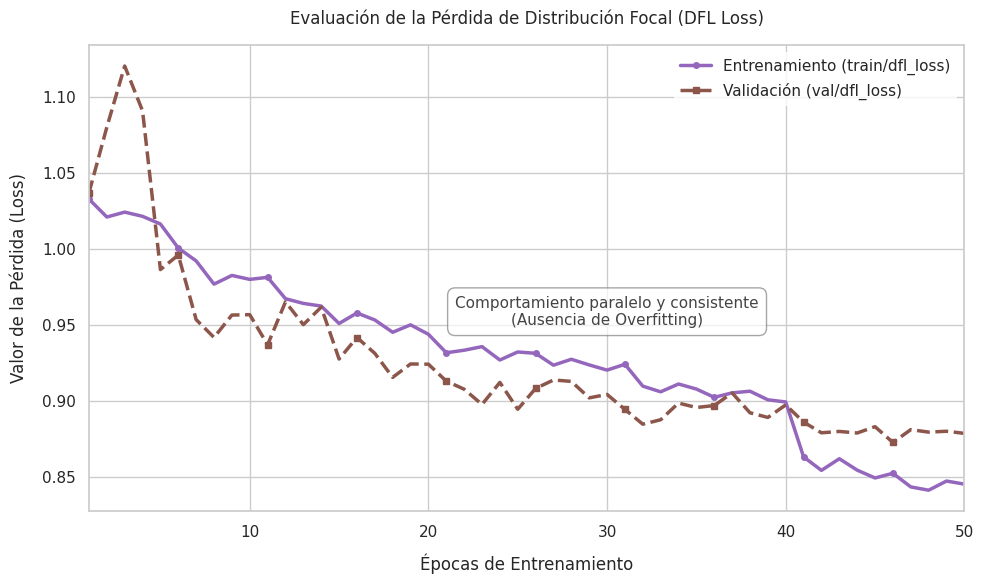

In [21]:
df = pd.read_csv('results.csv')
df.columns = df.columns.str.strip()

plt.figure(figsize=(10, 6))

plt.plot(df['epoch'], df['train/dfl_loss'],
         label='Entrenamiento (train/dfl_loss)',
         color='#9467bd', linewidth=2.5, marker='o', markersize=4, markevery=5)

plt.plot(df['epoch'], df['val/dfl_loss'],
         label='Validación (val/dfl_loss)',
         color='#8c564b', linewidth=2.5, linestyle='--', marker='s', markersize=4, markevery=5)

plt.title('Evaluación de la Pérdida de Distribución Focal (DFL Loss)', pad=15)
plt.xlabel('Épocas de Entrenamiento', labelpad=10)
plt.ylabel('Valor de la Pérdida (Loss)', labelpad=10)
plt.xlim(1, df['epoch'].max())

plt.text(30, 0.95, 'Comportamiento paralelo y consistente\n(Ausencia de Overfitting)',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.5'),
         fontsize=11, color='#444444', horizontalalignment='center')

plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.savefig('sustentacion_dfl_loss.png', dpi=300)
plt.show()

In [25]:
model = YOLO("/content/best.pt")

In [26]:
results = model("/content/Placas/ADG22H.jpg", save=True)


image 1/1 /content/Placas/ADG22H.jpg: 640x480 1 placa, 335.9ms
Speed: 11.9ms preprocess, 335.9ms inference, 37.6ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


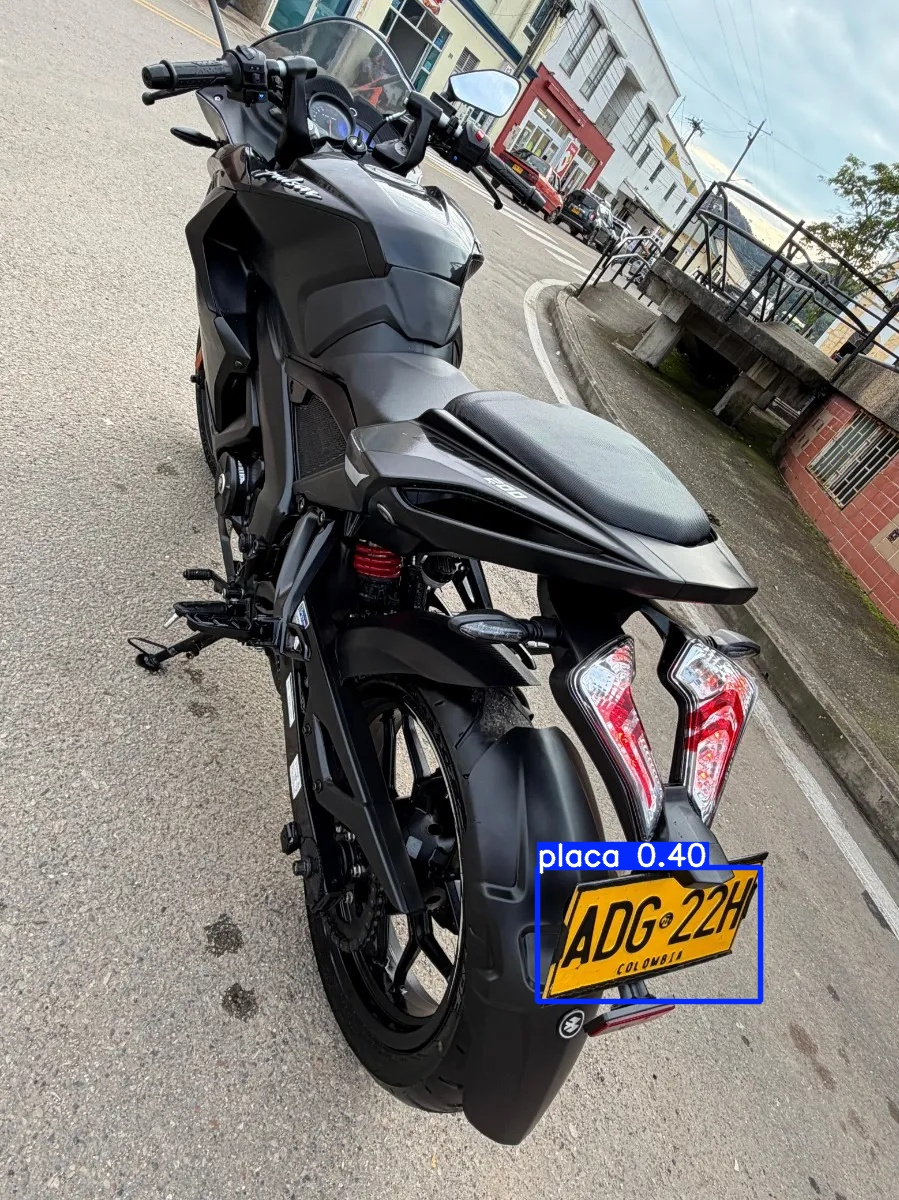

In [27]:
display(Image.open("/content/runs/detect/predict/ADG22H.jpg"))

In [28]:
for r in results:
  for box in r.boxes:
    # coordenadas
    print(box.xyxy)
    # confianza
    print(box.conf)
    # clase
    print(box.cls)

tensor([[ 537.6176,  867.5251,  760.5260, 1001.3527]])
tensor([0.3978])
tensor([0.])


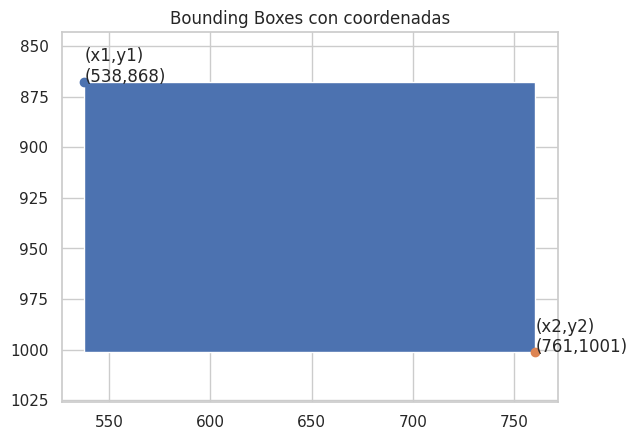

In [33]:
plt.figure()

for r in results:
    for box in r.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        ancho = x2 - x1
        alto = y2 - y1

        # rectangulo
        rect = plt.Rectangle((x1, y1), ancho, alto,)
        plt.gca().add_patch(rect)

        # puntos
        plt.scatter(x1, y1)
        plt.scatter(x2, y2)

        # etiquetas
        plt.text(x1, y1, f"(x1,y1)\n({x1:.0f},{y1:.0f})")
        plt.text(x2, y2, f"(x2,y2)\n({x2:.0f},{y2:.0f})")

plt.gca().invert_yaxis()
plt.axis('equal')
plt.title("Bounding Boxes con coordenadas")
plt.show()

In [34]:
carpeta = "/content/Placas"
carpeta_recortes = "/content/recortes"

os.makedirs(carpeta_recortes, exist_ok=True)

data = []

for nombre_img in os.listdir(carpeta):
    if nombre_img.lower().endswith((".jpg", ".png", ".jpeg")):

        ruta = os.path.join(carpeta, nombre_img)
        img = cv2.imread(ruta)

        results = model(img)

        for r in results:

            if len(r.boxes) == 0:
                continue

            # mejor detección
            best_box = max(r.boxes, key=lambda b: float(b.conf[0]))

            # coordenadas
            x1, y1, x2, y2 = best_box.xyxy[0].tolist()
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

            # padding
            padding = 5
            h, w, _ = img.shape

            x1 = max(0, x1 - padding)
            y1 = max(0, y1 - padding)
            x2 = min(w, x2 + padding)
            y2 = min(h, y2 + padding)

            # recorte
            placa = img[y1:y2, x1:x2]

            # guardar recorte
            nombre_salida = f"recorte_{nombre_img}"
            ruta_salida = os.path.join(carpeta_recortes, nombre_salida)
            cv2.imwrite(ruta_salida, placa)

            # cálculos
            ancho = x2 - x1
            largo = y2 - y1

            # guardar datos
            data.append([
                nombre_img,
                x1, y1, x2, y2,
                ancho,
                largo,
            ])

# dataframe
df = pd.DataFrame(data, columns=[
    "imagen",
    "x1", "y1", "x2", "y2",
    "ancho",
    "largo",
])

df.to_csv("resultados_coordenadas.csv", index=False)

print("Recortes guardados en:", carpeta_recortes)




0: 640x480 1 placa, 162.1ms
Speed: 4.7ms preprocess, 162.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)

0: 480x640 2 placas, 203.0ms
Speed: 4.5ms preprocess, 203.0ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 placas, 245.0ms
Speed: 6.2ms preprocess, 245.0ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 placa, 234.0ms
Speed: 10.3ms preprocess, 234.0ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 placas, 232.5ms
Speed: 4.3ms preprocess, 232.5ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 640x480 1 placa, 250.3ms
Speed: 4.5ms preprocess, 250.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)

0: 480x640 1 placa, 237.2ms
Speed: 6.0ms preprocess, 237.2ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 placa, 229.0ms
Speed: 5.1ms preprocess, 229.0ms inference, 1.3ms postprocess per image at sha

In [ ]:
df

,imagen,x1,y1,x2,y2,ancho,largo,ancho_menos_largo,ancho_div_2,largo_por_2
0,OVP34G.jpg,420,1348,863,1577,443,229,214,221.5,458
1,IWL480.jpg,243,568,390,700,147,132,15,73.5,264
2,KVN21G.jpg,460,449,638,547,178,98,80,89.0,196
3,DQS096.jpg,861,592,966,688,105,96,9,52.5,192
4,MKR084.jpg,430,495,637,594,207,99,108,103.5,198
...,...,...,...,...,...,...,...,...,...,...
92,NIZ121.jpg,847,555,986,688,139,133,6,69.5,266
93,GSZ821.jpg,490,400,661,489,171,89,82,85.5,178
94,GLM937.jpg,206,515,317,595,111,80,31,55.5,160
95,DIF77H.jpg,461,495,647,601,186,106,80,93.0,212


In [ ]:
!zip -r recortes.zip /content/recortes

  adding: content/recortes/ (stored 0%)
  adding: content/recortes/recorte_DUL56G.jpg (deflated 1%)
  adding: content/recortes/recorte_ONH67B.jpg (deflated 2%)
  adding: content/recortes/recorte_ZCN01G.jpg (deflated 2%)
  adding: content/recortes/recorte_LUS170.jpg (deflated 3%)
  adding: content/recortes/recorte_LVF42H.jpg (deflated 1%)
  adding: content/recortes/recorte_OGK65F.jpg (deflated 2%)
  adding: content/recortes/recorte_FZM790.jpg (deflated 3%)
  adding: content/recortes/recorte_IRN475.jpg (deflated 2%)
  adding: content/recortes/recorte_KWO280.jpg (deflated 2%)
  adding: content/recortes/recorte_JCX60H.jpg (deflated 1%)
  adding: content/recortes/recorte_HKM308.jpg (deflated 2%)
  adding: content/recortes/recorte_NCM842.jpg (deflated 2%)
  adding: content/recortes/recorte_NIZ121.jpg (deflated 2%)
  adding: content/recortes/recorte_GRM42E.jpg (deflated 2%)
  adding: content/recortes/recorte_ODY51G.jpg (deflated 2%)
  adding: content/recortes/recorte_KWP536.jpg (deflated 2%)


In [ ]:
model = YOLO("/content/runs/detect/train/weights/best.pt")

model.export(format="tflite", imgsz=320, half=True)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 5, 2100) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 271ms
Prepared 4 packages in 11.29s
Installed 4 packages in 319ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.1
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 12.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slim

'/content/runs/detect/train/weights/best_saved_model/best_float16.tflite'

In [ ]:
model = YOLO("/content/runs/detect/train/weights/best.pt")

model.export(
    format="tflite",
    imgsz=320,
    int8=True,
    data="/content/data.yaml"
)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 5, 2100) (5.9 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=/content/data.yaml'
Fast image access ✅ (ping: 0.0±0.0 ms, read: 424.9±297.6 MB/s, size: 12.7 KB)
Scanning /content/valid/labels.cache... 104 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 104/104 29.1Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 32, len(boxes) = 104. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
WARNING ⚠️ TensorFlow SavedModel: >300 images recommended for INT8 calibration, found 104 images.

ONNX: starting export with o

'/content/runs/detect/train/weights/best_saved_model/best_int8.tflite'

In [ ]:
model = YOLO("/content/runs/detect/train/weights/best.pt")
model.export(format="ncnn")

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ NCNN export does not support end2end models, disabling end2end branch.
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.9 MB)
requirements: Ultralytics requirement ['ncnn'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 1 package in 203ms
Prepared 1 package in 195ms
Installed 1 package in 1ms
 + ncnn==1.0.20260114

requirements: AutoUpdate success ✅ 0.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

requirements: Ultralytics requirement ['pnnx'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 29 packages in 303ms
Prepared 1 package in 526ms
Installed 1 package in 2ms
 + pnnx==20260409

requirements: Au

'/content/runs/detect/train/weights/best_ncnn_model'

In [45]:
!unzip best_ncnn_model.zip

Archive:  best_ncnn_model.zip
   creating: best_ncnn_model/
  inflating: best_ncnn_model/metadata - copia.yaml  
  inflating: best_ncnn_model/metadata.yaml  
  inflating: best_ncnn_model/model.ncnn - copia.bin  
  inflating: best_ncnn_model/model.ncnn - copia.param  
  inflating: best_ncnn_model/model.ncnn.bin  
  inflating: best_ncnn_model/model.ncnn.param  
  inflating: best_ncnn_model/model_ncnn - copia.py  
  inflating: best_ncnn_model/model_ncnn.py  


In [52]:
modelo_f32 = YOLO("/content//best_float32.tflite", task="detect")
modelo_f16 = YOLO("/content/best_float16.tflite", task="detect")
modelo_int8 = YOLO("/content/best_int8.tflite", task="detect")
modelo_ncnn = YOLO("/content/best_ncnn_model", task="detect")


img_prueba = "Placas/ADG22H.jpg"

def medir_rendimiento(modelo, nombre):
    modelo.predict(img_prueba, imgsz=320, conf=0.1, verbose=False)

    tiempos = []
    for _ in range(10):
        start = time.time()
        res = modelo.predict(img_prueba, imgsz=320, verbose=False)
        tiempos.append(time.time() - start)

    promedio = np.mean(tiempos) * 1000
    print(f"--- {nombre} ---")
    print(f"Tiempo promedio: {promedio:.2f} ms")
    print(f"Detecciones: {len(res[0].boxes)} placa(s) encontrada(s)\n")
    return promedio

t_f32 = medir_rendimiento(modelo_f32, "Modelo FLOAT32")
t_f16 = medir_rendimiento(modelo_f16, "Modelo FLOAT16")
t_int8 = medir_rendimiento(modelo_int8, "Modelo INT8")
t_ncnn = medir_rendimiento(modelo_ncnn, "Modelo NCNN")

Loading /content//best_float32.tflite for TensorFlow Lite inference...
--- Modelo FLOAT32 ---
Tiempo promedio: 76.99 ms
Detecciones: 1 placa(s) encontrada(s)

Loading /content/best_float16.tflite for TensorFlow Lite inference...
--- Modelo FLOAT16 ---
Tiempo promedio: 95.38 ms
Detecciones: 1 placa(s) encontrada(s)

Loading /content/best_int8.tflite for TensorFlow Lite inference...
--- Modelo INT8 ---
Tiempo promedio: 122.26 ms
Detecciones: 1 placa(s) encontrada(s)

Loading /content/best_ncnn_model for NCNN inference...
--- Modelo NCNN ---
Tiempo promedio: 215.56 ms
Detecciones: 300 placa(s) encontrada(s)



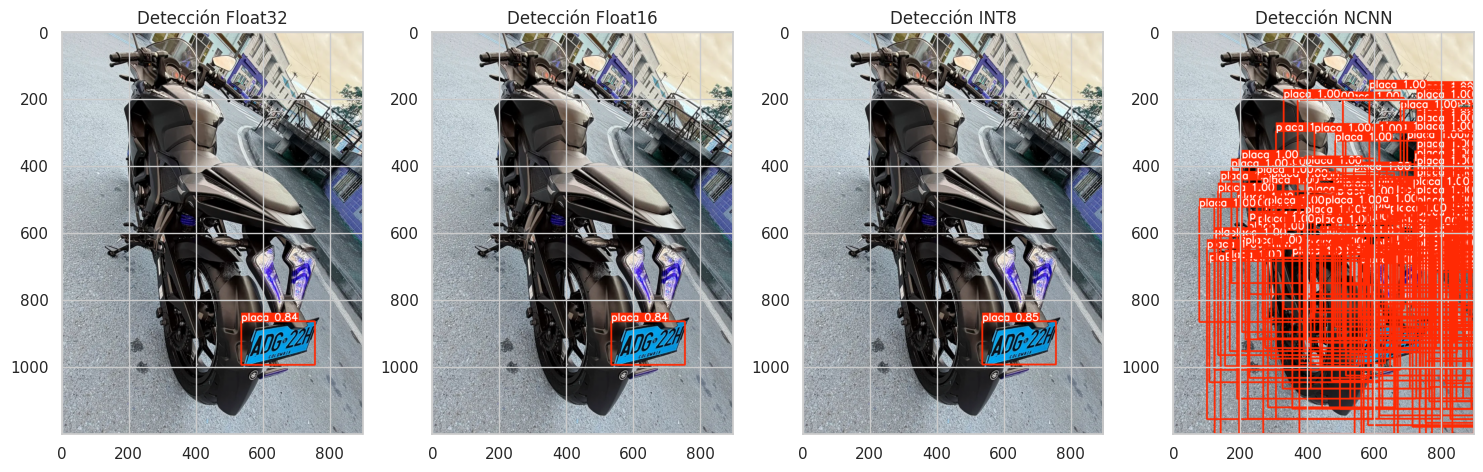

In [57]:
res_f32 = modelo_f32.predict(img_prueba, imgsz=320)[0].plot()
res_f16 = modelo_f16.predict(img_prueba, imgsz=320)[0].plot()
res_int8 = modelo_int8.predict(img_prueba, imgsz=320)[0].plot()
res_ncnn = modelo_ncnn.predict(img_prueba, imgsz=320)[0].plot()

fig, ax = plt.subplots(1, 4, figsize=(15, 7))
ax[0].imshow(res_f32)
ax[0].set_title("Detección Float32")
ax[2].imshow(res_int8)
ax[1].set_title("Detección Float16")
ax[3].imshow(res_ncnn)
ax[2].set_title("Detección INT8")
ax[1].imshow(res_f16)
ax[3].set_title("Detección NCNN")
plt.tight_layout()
plt.show()